In [1]:

!pip install -q timm kagglehub
print(" Dependencies installed")


 Dependencies installed


In [2]:


model_utils_code = """
import torch
import torch.nn as nn
import timm
from torchvision import transforms

class RiceMobileNetV4(nn.Module):
    def __init__(self, num_classes=3):
        super(RiceMobileNetV4, self).__init__()
        self.model = timm.create_model(
            "mobilenetv4_conv_small.e2400_r224_in1k", pretrained=True
        )
        n_features = self.model.classifier.in_features

        # Freeze ALL backbone layers first
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze last 2 blocks for phase 1
        for param in self.model.blocks[-1].parameters():
            param.requires_grad = True
        for param in self.model.blocks[-2].parameters():
            param.requires_grad = True

        # Better classifier head with BatchNorm
        self.model.classifier = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

    def unfreeze_all(self):
        for param in self.model.parameters():
            param.requires_grad = True


def get_train_transforms():
    return transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.2, hue=0.05),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2),
    ])


def get_eval_transforms():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
"""

with open("model_utils.py", "w") as f:
    f.write(model_utils_code)

print(" model_utils.py saved")

 model_utils.py saved


In [3]:

import kagglehub, os

base_path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")

data_dir = None
for root, dirs, files in os.walk(base_path):
    if 'Bacterial leaf blight' in dirs:
        data_dir = root
        break

if data_dir:
    print(f"✅ Dataset found at: {data_dir}")
    for cls in os.listdir(data_dir):
        count = len(os.listdir(os.path.join(data_dir, cls)))
        print(f"   {cls}: {count} images")
else:
    print(" Dataset not found. Check Kaggle credentials.")


Using Colab cache for faster access to the 'rice-leaf-diseases' dataset.
✅ Dataset found at: /kaggle/input/rice-leaf-diseases/rice_leaf_diseases
   Brown spot: 40 images
   Bacterial leaf blight: 40 images
   Leaf smut: 40 images


In [ ]:

import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets
from model_utils import RiceMobileNetV4, get_train_transforms, get_eval_transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

train_dataset = datasets.ImageFolder(root=data_dir, transform=get_train_transforms())
val_dataset   = datasets.ImageFolder(root=data_dir, transform=get_eval_transforms())
print(f"Classes: {train_dataset.classes}")
num_classes = len(train_dataset.classes)

n       = len(train_dataset)
n_train = int(0.85 * n)
torch.manual_seed(42)
indices   = torch.randperm(n).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:]

train_data = Subset(train_dataset, train_idx)
val_data   = Subset(val_dataset,   val_idx)

#Weighted
targets      = [train_dataset.targets[i] for i in train_idx]
class_counts = np.bincount(targets)
sample_wts   = 1.0 / class_counts[targets]
sampler      = WeightedRandomSampler(sample_wts, num_samples=len(sample_wts), replacement=True)

#DataLoaders
train_loader = DataLoader(train_data, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False,   num_workers=2, pin_memory=True)

# Model & loss
model     = RiceMobileNetV4(num_classes=num_classes).to(device)
class_wts = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_wts, label_smoothing=0.1)


print("\n── Phase 1: Training head ")
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
best_val_acc = 0.0
no_improve   = 0

def run_epoch(model, loader, criterion, optimizer, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total

for epoch in range(15):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    _,          val_acc   = run_epoch(model, val_loader,   criterion, optimizer, train=False)
    scheduler.step()
    print(f"  Epoch {epoch+1:2d}/15 | Loss: {train_loss:.4f} | "
          f"Train: {train_acc*100:.1f}% | Val: {val_acc*100:.1f}%", end="")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save({"model_state": model.state_dict(),
                    "classes":     train_dataset.classes,
                    "val_idx":     val_idx}, "rice_model.pth")
        print(f"  ✓ saved")
    else:
        no_improve += 1
        print()
        if no_improve >= 5:
            print("  Early stopping phase 1")
            break

# Fine-tuning

print(f"\n Full fine-tuning (best so far: {best_val_acc*100:.1f}%) ──")
model.unfreeze_all()
optimizer = optim.AdamW([
    {"params": model.model.blocks.parameters(),     "lr": 1e-5},
    {"params": model.model.classifier.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)
no_improve = 0

for epoch in range(25):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    _,          val_acc   = run_epoch(model, val_loader,   criterion, optimizer, train=False)
    scheduler.step()
    print(f"  Epoch {epoch+1:2d}/25 | Loss: {train_loss:.4f} | "
          f"Train: {train_acc*100:.1f}% | Val: {val_acc*100:.1f}%", end="")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save({"model_state": model.state_dict(),
                    "classes":     train_dataset.classes,
                    "val_idx":     val_idx}, "rice_model.pth")
        print(f"saved")
    else:
        no_improve += 1
        print()
        if no_improve >= 7:
            print("  Early stopping phase 2")
            break

print(f" Training complete! Best val acc: {best_val_acc*100:.1f}%")


Training on: cuda
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

── Phase 1: Training head + last 2 blocks ──
  Epoch  1/15 | Loss: 0.9903 | Train: 41.2% | Val: 61.1%  ✓ saved
  Epoch  2/15 | Loss: 0.8450 | Train: 70.6% | Val: 72.2%  ✓ saved
  Epoch  3/15 | Loss: 0.6865 | Train: 74.5% | Val: 83.3%  ✓ saved
  Epoch  4/15 | Loss: 0.6678 | Train: 72.5% | Val: 88.9%  ✓ saved
  Epoch  5/15 | Loss: 0.8458 | Train: 77.5% | Val: 88.9%
  Epoch  6/15 | Loss: 0.7079 | Train: 85.3% | Val: 88.9%
  Epoch  7/15 | Loss: 0.7826 | Train: 82.4% | Val: 77.8%
  Epoch  8/15 | Loss: 0.6967 | Train: 83.3% | Val: 66.7%
  Epoch  9/15 | Loss: 0.6045 | Train: 83.3% | Val: 61.1%
  Early stopping phase 1

 Full fine-tuning (best so far: 88.9%) ──
  Epoch  1/25 | Loss: 0.6962 | Train: 86.3% | Val: 72.2%
  Epoch  2/25 | Loss: 0.5951 | Train: 88.2% | Val: 77.8%
  Epoch  3/25 | Loss: 0.5707 | Train: 89.2% | Val: 72.2%
  Epoch  4/25 | Loss: 0.7544 | Train: 86.3% | Val: 72.2%
  Epoch  5/25 | Loss: 0.5202 

Classification Report 
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.80      0.89         5
           Brown spot       0.83      1.00      0.91        10
            Leaf smut       1.00      0.67      0.80         3

             accuracy                           0.89        18
            macro avg       0.94      0.82      0.87        18
         weighted avg       0.91      0.89      0.89        18



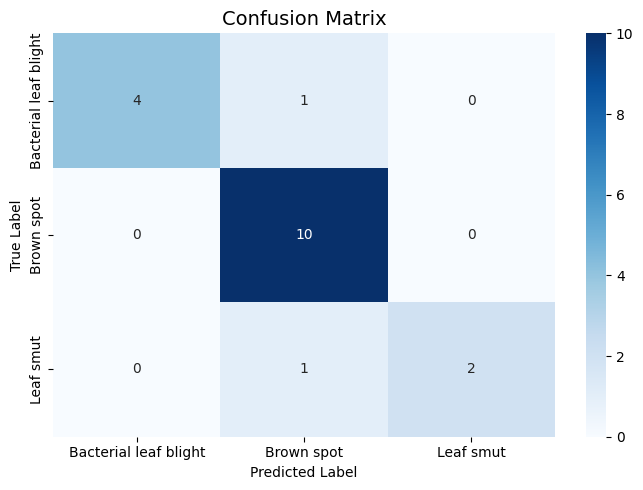

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

checkpoint = torch.load("rice_model.pth", map_location=device)
classes    = checkpoint["classes"]
val_idx    = checkpoint["val_idx"]

eval_dataset = datasets.ImageFolder(root=data_dir, transform=get_eval_transforms())
test_data    = Subset(eval_dataset, val_idx)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

model = RiceMobileNetV4(num_classes=len(classes)).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report ")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


Saving Brown-spot-Daren-Mueller-35-1300x867.jpg to Brown-spot-Daren-Mueller-35-1300x867 (1).jpg
Result: ⚠️ Brown spot detected
Confidence: 96.4%


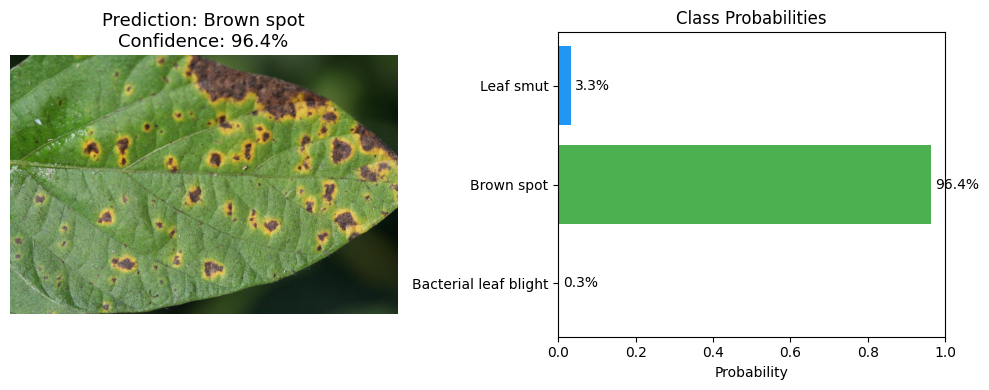

In [ ]:

import torch.nn.functional as F
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt


uploaded = files.upload()
image_path = list(uploaded.keys())[0]

checkpoint = torch.load("rice_model.pth", map_location=device)
classes    = checkpoint["classes"]
model      = RiceMobileNetV4(num_classes=len(classes)).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

# Predict
transform = get_eval_transforms()
image     = Image.open(image_path).convert('RGB')
tensor    = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    probs      = F.softmax(model(tensor), dim=1)[0]
    conf, pred = torch.max(probs, dim=0)


HEALTHY_THRESHOLD = 0.75

if conf.item() < HEALTHY_THRESHOLD:
    result = "Healthy"
else:
    result = f"{classes[pred.item()]} detected"

print(f"Result: {result}")
print(f"Confidence: {conf.item()*100:.1f}%")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(image)
ax1.set_title(f"Prediction: {classes[pred.item()]}\nConfidence: {conf.item()*100:.1f}%", fontsize=13)
ax1.axis('off')

colors = ['#2196F3' if i != pred.item() else '#4CAF50' for i in range(len(classes))]
ax2.barh(classes, probs.cpu().numpy(), color=colors)
ax2.set_xlim(0, 1)
ax2.set_xlabel("Probability")
ax2.set_title("Class Probabilities")
for i, p in enumerate(probs.cpu().numpy()):
    ax2.text(p + 0.01, i, f"{p*100:.1f}%", va='center')

plt.tight_layout()
plt.show()


In [ ]:

from google.colab import files
files.download("rice_model.pth")
print("✅ rice_model.pth downloaded!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ rice_model.pth downloaded!
